In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
trades = pd.read_csv("datasets/historical_data.csv")
sentiment = pd.read_csv("datasets/fear_greed_index.csv")

In [28]:
trades.head()
trades.shape

(211224, 16)

In [29]:
sentiment.head()
sentiment.shape

(2644, 4)

In [30]:
trades.columns = trades.columns.str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.lower().str.replace(" ", "_")

In [31]:
trades.columns
# sentiment.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='str')

In [32]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)

In [33]:
trades['timestamp_ist'].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: timestamp_ist, dtype: datetime64[us]

In [34]:
trades['date'] = trades['timestamp_ist'].dt.date

In [35]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [36]:
trades.isnull().sum()
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [37]:
trades = trades[['account','coin','execution_price','size_usd','side',
                 'direction','closed_pnl','fee','date','trade_id']]

In [38]:
data = pd.merge(trades, sentiment[['date','classification','value']], on='date', how='inner')

In [39]:
data.head()

,account,coin,execution_price,size_usd,side,direction,closed_pnl,fee,date,trade_id,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,7872.16,BUY,Buy,0.0,0.345404,2024-12-02,8.950000e+14,Extreme Greed,80
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,127.68,BUY,Buy,0.0,0.005600,2024-12-02,4.430000e+14,Extreme Greed,80
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,1150.63,BUY,Buy,0.0,0.050431,2024-12-02,6.600000e+14,Extreme Greed,80
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,1142.04,BUY,Buy,0.0,0.050043,2024-12-02,1.080000e+15,Extreme Greed,80
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,69.75,BUY,Buy,0.0,0.003055,2024-12-02,1.050000e+15,Extreme Greed,80


In [40]:
data.isnull().sum()

account            0
coin               0
execution_price    0
size_usd           0
side               0
direction          0
closed_pnl         0
fee                0
date               0
trade_id           0
classification     0
value              0
dtype: int64

In [41]:
data['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [42]:
data['closed_pnl'].describe()

count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: closed_pnl, dtype: float64

In [43]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 211218 entries, 0 to 211217
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   account          211218 non-null  str    
 1   coin             211218 non-null  str    
 2   execution_price  211218 non-null  float64
 3   size_usd         211218 non-null  float64
 4   side             211218 non-null  str    
 5   direction        211218 non-null  str    
 6   closed_pnl       211218 non-null  float64
 7   fee              211218 non-null  float64
 8   date             211218 non-null  object 
 9   trade_id         211218 non-null  float64
 10  classification   211218 non-null  str    
 11  value            211218 non-null  int64  
dtypes: float64(5), int64(1), object(1), str(5)
memory usage: 19.3+ MB


In [44]:
data.duplicated().sum()

np.int64(229)

In [45]:
data.drop_duplicates(inplace=True)

In [46]:
data.shape

(210989, 12)

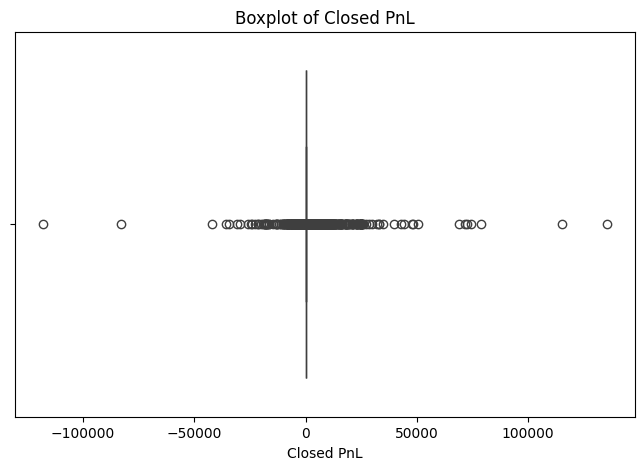

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.boxplot(x=data['closed_pnl'])
plt.title('Boxplot of Closed PnL')
plt.xlabel('Closed PnL')
plt.show()

In [48]:
Q1 = data['closed_pnl'].quantile(0.25)
Q3 = data['closed_pnl'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['closed_pnl'] < lower_bound) | (data['closed_pnl'] > upper_bound)]
print(f"Number of outliers:",len(outliers))

Number of outliers: 48902


keeping outliers as they r important for trading.


EDA

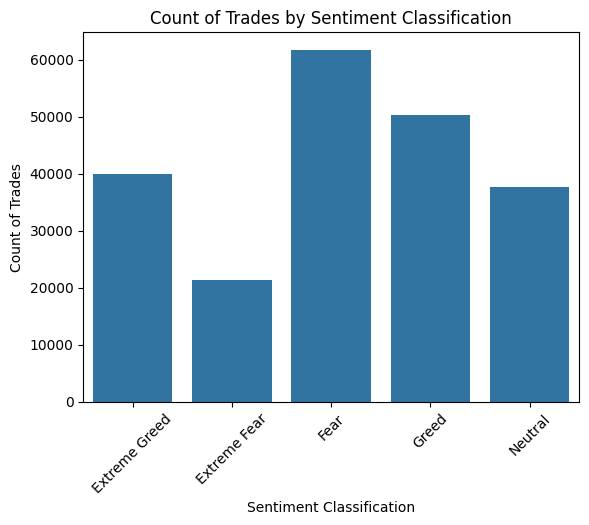

In [83]:
sentiment_count = data['classification'].value_counts()
sns.countplot(x='classification', data=data)
plt.title('Count of Trades by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Count of Trades')
plt.xticks(rotation=45)
plt.show()

  classification  trade_id
0   Extreme Fear     21344
1  Extreme Greed     39963
2           Fear     61746
3          Greed     50283
4        Neutral     37653


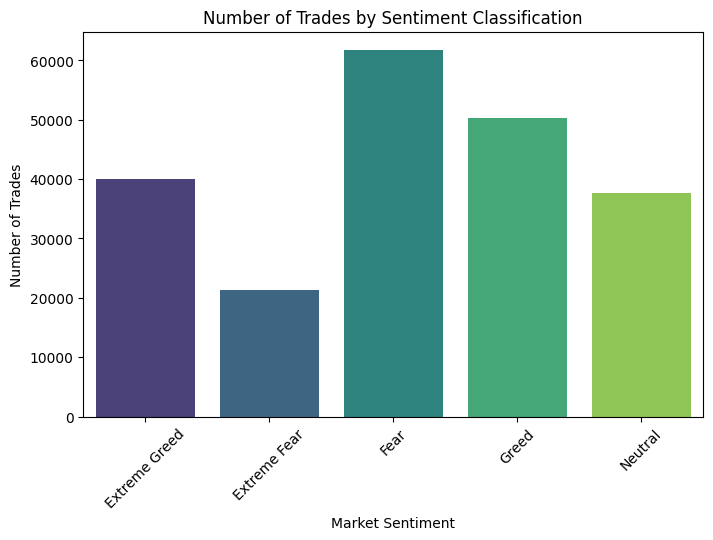

In [54]:
# trade vs sentiment

trades_by_sentiment = data.groupby('classification')['trade_id'].count().reset_index()
print(trades_by_sentiment)
plt.figure(figsize=(8,5))

sns.countplot(
    x='classification',
    data=data,
    hue='classification',
    palette='viridis',
    legend=False
)

plt.title("Number of Trades by Sentiment Classification")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)
plt.show()

  classification  closed_pnl
0   Extreme Fear   34.632361
1  Extreme Greed   67.931417
2           Fear   54.353074
3          Greed   42.756803
4        Neutral   34.335977


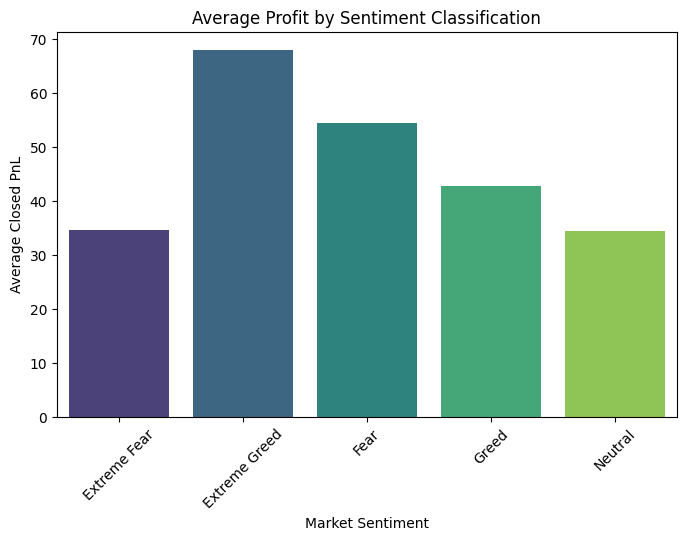

In [57]:
# /avg profit by sentiment
avg_profit_by_sentiment = data.groupby('classification')['closed_pnl'].mean().reset_index()
print(avg_profit_by_sentiment)

plt.figure(figsize=(8,5))

sns.barplot(
    x='classification',
    y='closed_pnl',
    data=avg_profit_by_sentiment,
    hue='classification',
    palette='viridis',
    legend=False
)

plt.title("Average Profit by Sentiment Classification")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)
plt.show()

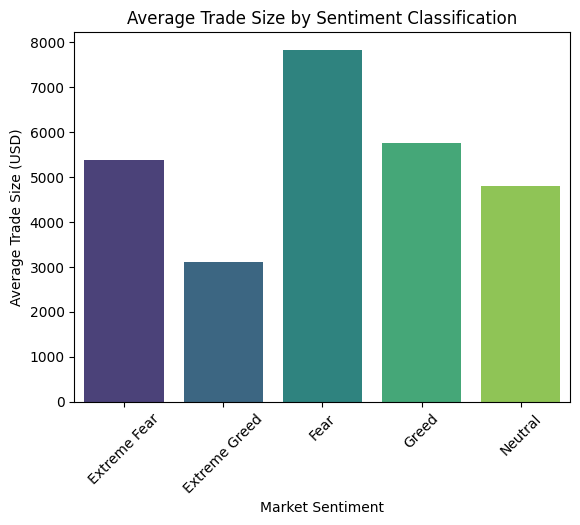

In [ ]:
# size vs sentiment
sentiment_by_size =data.groupby('classification')['size_usd'].mean().reset_index()
sns.barplot(
    x='classification',
    y='size_usd',
    data=sentiment_by_size,
    hue='classification',
    palette='viridis',
    legend=False
)
plt.title("Average Trade Size by Sentiment Classification")
plt.xlabel("Market Sentiment")  
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)
plt.show()

                    direction    closed_pnl
0           Auto-Deleveraging   7184.807003
1                         Buy      0.000000
2                  Close Long     74.504738
3                 Close Short    101.935246
4   Liquidated Isolated Short -12752.913040
5                Long > Short     34.936474
6                   Open Long      0.000000
7                  Open Short      0.000000
8                        Sell    146.159235
9                  Settlement    -29.215368
10               Short > Long    154.190415
11       Spot Dust Conversion      0.000000


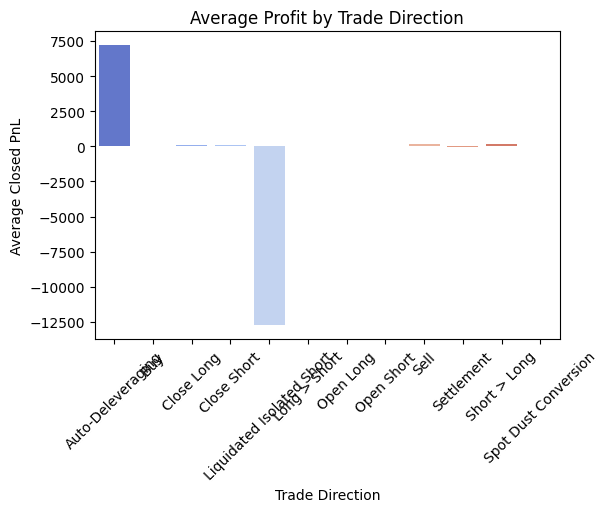

In [ ]:
# direction vs profit
direction_performance = data.groupby(['direction'])['closed_pnl'].mean().reset_index()
print(direction_performance)
plt.figure(figsize=(6,4))

sns.barplot(
    x='direction',
    y='closed_pnl',
    data=direction_performance,
    hue='direction',
    palette='coolwarm',
    legend=False
)

plt.title("Average Profit by Trade Direction")
plt.xlabel("Trade Direction")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)

plt.show()

for clearer  version lets take only long and short

  trade_type  closed_pnl
0       Long   36.793762
1      Short   48.458479


C:\Users\Tasneem Inayath\AppData\Local\Temp\ipykernel_42508\1691404580.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


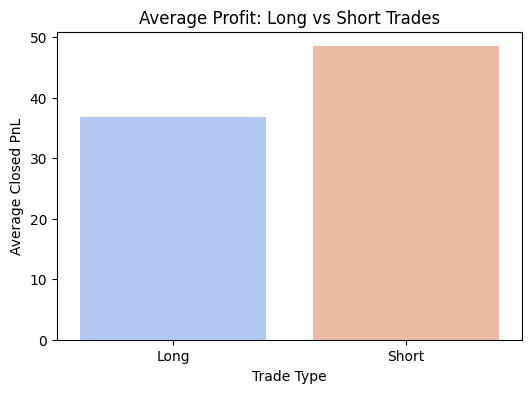

In [68]:
filtered_data = data[data['direction'].isin([
    'Open Long', 'Close Long', 'Open Short', 'Close Short'
])]
filtered_data['trade_type'] = filtered_data['direction'].apply(
    lambda x: 'Long' if 'Long' in x else 'Short'
)
trade_type_performance = filtered_data.groupby(['trade_type'])['closed_pnl'].mean().reset_index()
print(trade_type_performance)
plt.figure(figsize=(6,4))

sns.barplot(
    x='trade_type',
    y='closed_pnl',
    data=trade_type_performance,
    palette='coolwarm'
)

plt.title("Average Profit: Long vs Short Trades")
plt.xlabel("Trade Type")
plt.ylabel("Average Closed PnL")

plt.show()


Higher sentiment values (Greed) tend to correspond with higher trading profits.

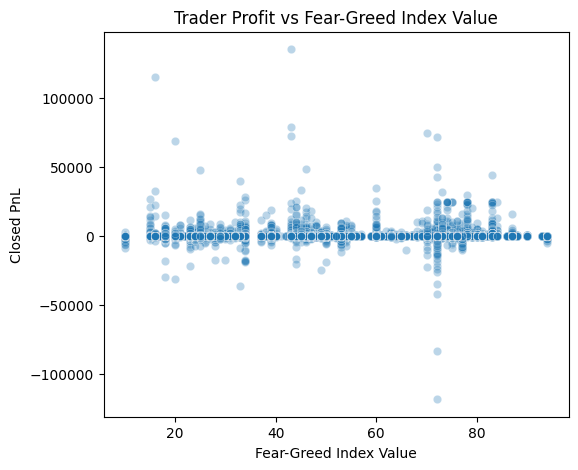

In [69]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x='value',
    y='closed_pnl',
    data=data,
    alpha=0.3
)

plt.title("Trader Profit vs Fear-Greed Index Value")
plt.xlabel("Fear-Greed Index Value")
plt.ylabel("Closed PnL")

plt.show()

In [70]:
top_traders = data.groupby('account')['closed_pnl'].sum().sort_values(ascending=False).head(10)

print(top_traders)

account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.142990e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.599742e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401500e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.403232e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360452e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777223e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.292823e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.163518e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790508e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605632e+05
Name: closed_pnl, dtype: float64


In [81]:
numeric_cols = data[['execution_price','size_usd','closed_pnl','fee','value']]
correlation_matrix = numeric_cols.corr()
print(correlation_matrix)

                 execution_price  size_usd  closed_pnl       fee     value
execution_price         1.000000  0.190081   -0.006415  0.225536 -0.027372
size_usd                0.190081  1.000000    0.123639  0.745934 -0.029932
closed_pnl             -0.006415  0.123639    1.000000  0.084088  0.008100
fee                     0.225536  0.745934    0.084088  1.000000 -0.026977
value                  -0.027372 -0.029932    0.008100 -0.026977  1.000000


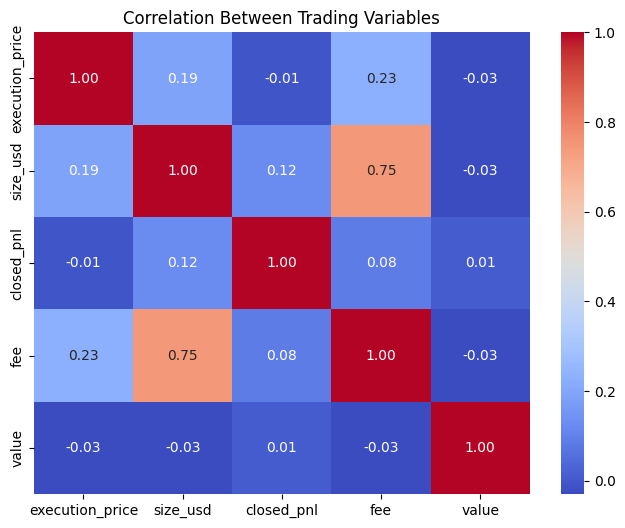

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Trading Variables")

plt.show()

For finding trading behaviour patterns we are going to use K means clustering a Unsupervised Learning Algorithm.

In [84]:
from sklearn.preprocessing import StandardScaler

features = data[['size_usd','closed_pnl','value']]

In [85]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [88]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
data['cluster'] = kmeans.fit_predict(scaled_features)
centroids = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids)
centroid_df = pd.DataFrame(
    centroids_original,
    columns=['size_usd','closed_pnl','value']
)

print(centroid_df)

       size_usd    closed_pnl      value
0  6.249213e+03     36.664259  35.159532
1  4.110202e+03     51.823015  72.478102
2  1.417613e+06  21666.582496  45.137255


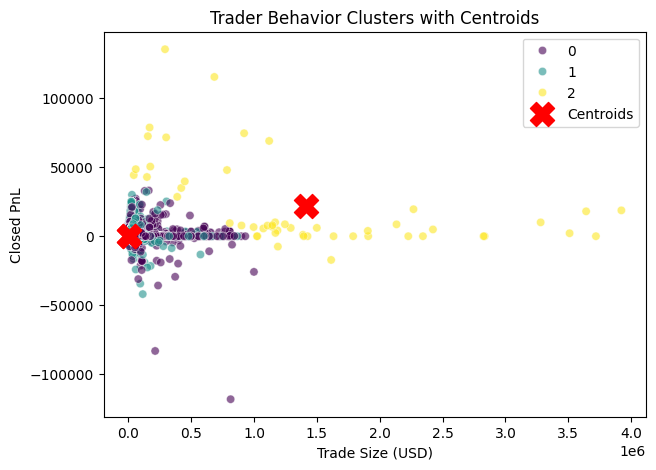

In [91]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=data['size_usd'],
    y=data['closed_pnl'],
    hue=data['cluster'],
    palette='viridis',
    alpha=0.6
)

plt.scatter(
    centroid_df['size_usd'],
    centroid_df['closed_pnl'],
    c='red',
    s=300,
    marker='X',
    label='Centroids'
)

plt.title("Trader Behavior Clusters with Centroids")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Closed PnL")

plt.legend()
plt.show()

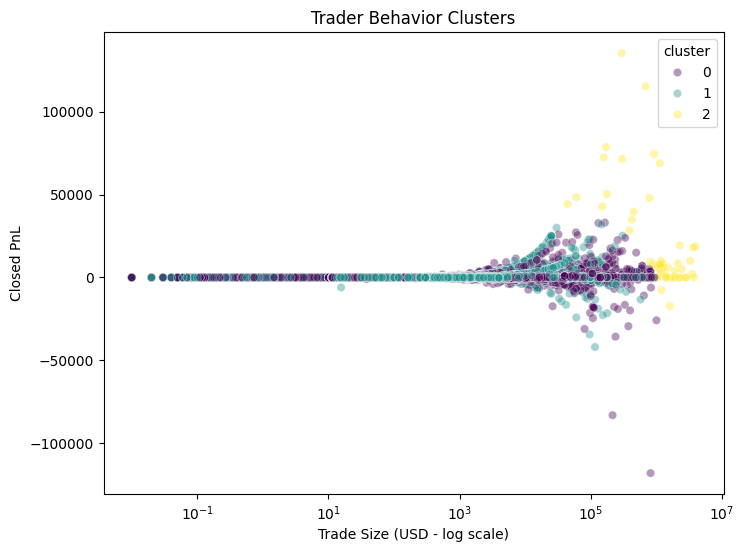

In [92]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=data['size_usd'],
    y=data['closed_pnl'],
    hue=data['cluster'],
    palette='viridis',
    alpha=0.4
)

plt.xscale('log')

plt.title("Trader Behavior Clusters")
plt.xlabel("Trade Size (USD - log scale)")
plt.ylabel("Closed PnL")

plt.show()